

Install / import libraries









In [2]:
# SUPPLYPRESCRIPT - SECTION 1
# Data Ingestion + Cleaning + Feature Engineering + EDA


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


Upload dataset

In [4]:
from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print("-", filename)

Saving DataCoSupplyChainDataset.csv to DataCoSupplyChainDataset.csv
Saving DescriptionDataCoSupplyChain.csv to DescriptionDataCoSupplyChain.csv
Saving tokenized_access_logs.csv to tokenized_access_logs.csv

Uploaded files:
- DataCoSupplyChainDataset.csv
- DescriptionDataCoSupplyChain.csv
- tokenized_access_logs.csv


Load the main dataset

In [5]:
DATA_FILE = "DataCoSupplyChainDataset.csv"

df = pd.read_csv(
    DATA_FILE,
    encoding="latin1"
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (180519, 53)


Load data dictionary

In [6]:
DESCRIPTION_FILE = "DescriptionDataCoSupplyChain.csv"

description = pd.read_csv(
    DESCRIPTION_FILE,
    encoding="latin1"
)

print("Data dictionary loaded.")
print("Shape:", description.shape)

display(description.head())

Data dictionary loaded.
Shape: (52, 2)


,FIELDS,DESCRIPTION
0,Type,: Type of transaction made
1,Days for shipping (real),: Actual shipping days of the purchased product
2,Days for shipment (scheduled),: Days of scheduled delivery of the purchased...
3,Benefit per order,: Earnings per order placed
4,Sales per customer,: Total sales per customer made per customer


Dataset overview

In [7]:
print(" DATASET OVERVIEW ")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMemory usage:")
print(f"{df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

print("\nFirst 5 rows:")
display(df.head())

 DATASET OVERVIEW 
Rows: 180519
Columns: 53

Memory usage:
298.92 MB

First 5 rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


Column information

In [8]:
column_info = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Unique_Values": [df[col].nunique(dropna=True) for col in df.columns],
    "Missing_Count": [df[col].isna().sum() for col in df.columns],
    "Missing_Percentage": [
        df[col].isna().mean() * 100 for col in df.columns
    ]
})

display(column_info)

,Column,Data_Type,Unique_Values,Missing_Count,Missing_Percentage
0,Type,object,4,0,0.000000
1,Days for shipping (real),int64,7,0,0.000000
2,Days for shipment (scheduled),int64,4,0,0.000000
3,Benefit per order,float64,21998,0,0.000000
4,Sales per customer,float64,2927,0,0.000000
5,Delivery Status,object,4,0,0.000000
6,Late_delivery_risk,int64,2,0,0.000000
7,Category Id,int64,51,0,0.000000
8,Category Name,object,50,0,0.000000
9,Customer City,object,563,0,0.000000


Separate numerical and categorical columns

In [9]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical columns:", len(numerical_columns))
print("Categorical columns:", len(categorical_columns))

print("\nNumerical:")
print(numerical_columns)

print("\nCategorical:")
print(categorical_columns)

Numerical columns: 29
Categorical columns: 24

Numerical:
['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Id', 'Customer Id', 'Customer Zipcode', 'Department Id', 'Latitude', 'Longitude', 'Order Customer Id', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Price', 'Product Status']

Categorical:
['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Region', 'Order State', 

Missing value analysis

In [10]:
missing_report = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing_report = missing_report.sort_values(
    "Missing_Percentage",
    ascending=False
)

display(missing_report[missing_report["Missing_Count"] > 0])

,Missing_Count,Missing_Percentage
Product Description,180519,100.000000
Order Zipcode,155679,86.239676
Customer Lname,8,0.004432
Customer Zipcode,3,0.001662


Missing-value graph

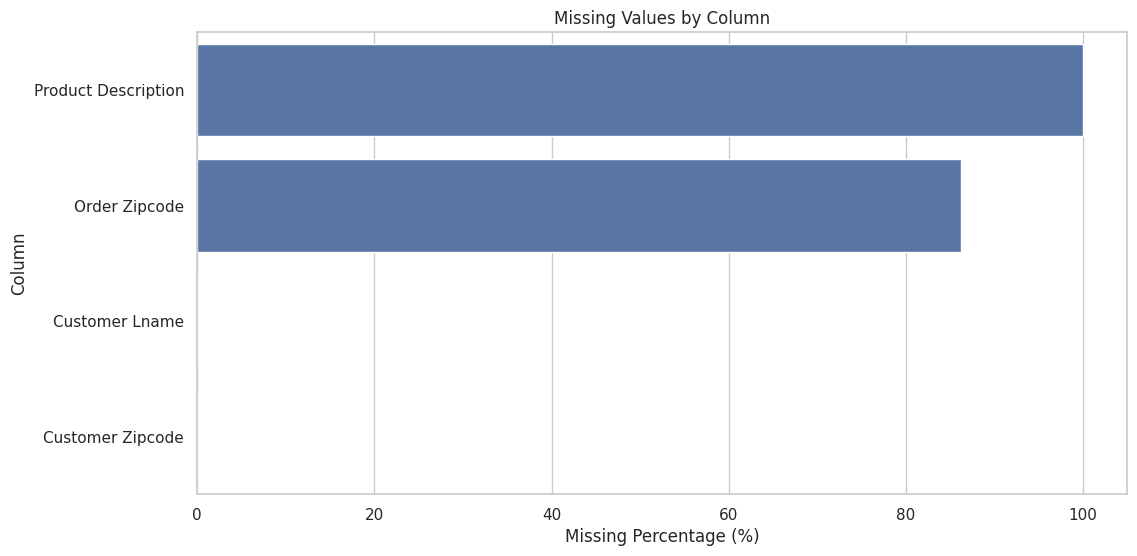

In [11]:
missing_nonzero = missing_report[
    missing_report["Missing_Count"] > 0
]

if not missing_nonzero.empty:

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=missing_nonzero["Missing_Percentage"],
        y=missing_nonzero.index
    )

    plt.title("Missing Values by Column")
    plt.xlabel("Missing Percentage (%)")
    plt.ylabel("Column")

    plt.show()

else:
    print("No missing values found.")

Duplicate analysis

In [12]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = duplicate_count / len(df) * 100

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", round(duplicate_percentage, 4), "%")

Duplicate rows: 0
Duplicate percentage: 0.0 %


Target analysis

Late_delivery_risk

In [13]:
TARGET = "Late_delivery_risk"

print("Target column:", TARGET)

print("\nTarget values:")
print(df[TARGET].value_counts())

print("\nTarget percentages:")
print(
    (df[TARGET].value_counts(normalize=True) * 100).round(2)
)

Target column: Late_delivery_risk

Target values:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Target percentages:
Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64


Target graph

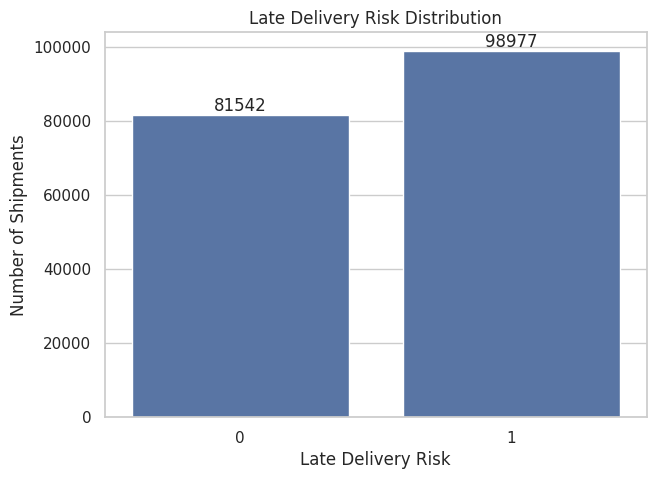

In [14]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x=TARGET
)

plt.title("Late Delivery Risk Distribution")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Number of Shipments")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Target summary table

In [15]:
target_summary = pd.DataFrame({
    "Count": df[TARGET].value_counts(),
    "Percentage": df[TARGET].value_counts(normalize=True) * 100
})

target_summary.index.name = TARGET

display(target_summary)

,Count,Percentage
Late_delivery_risk,,
1,98977,54.829132
0,81542,45.170868


Numerical statistics

In [16]:
numerical_summary = df[numerical_columns].describe().T

display(numerical_summary)

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


Check invalid negative values

In [17]:
negative_values = {}

for col in numerical_columns:
    count = (df[col] < 0).sum()

    if count > 0:
        negative_values[col] = count

negative_values

{'Benefit per order': np.int64(33784),
 'Latitude': np.int64(9),
 'Longitude': np.int64(180414),
 'Order Item Profit Ratio': np.int64(33784),
 'Order Profit Per Order': np.int64(33784)}

Outlier analysis function

In [18]:
def calculate_outliers(data, columns):

    results = []

    for col in columns:

        series = data[col].dropna()

        if len(series) == 0:
            continue

        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_count = (
            (series < lower_bound) |
            (series > upper_bound)
        ).sum()

        results.append({
            "Column": col,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower_Bound": lower_bound,
            "Upper_Bound": upper_bound,
            "Outlier_Count": outlier_count,
            "Outlier_Percentage": (
                outlier_count / len(series) * 100
            )
        })

    return pd.DataFrame(results)


outlier_report = calculate_outliers(
    df,
    numerical_columns
)

display(
    outlier_report.sort_values(
        "Outlier_Percentage",
        ascending=False
    )
)

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
2,Benefit per order,7.000000,64.800003,57.800003,-79.700005,151.500008,18942,10.493078
22,Order Profit Per Order,7.000000,64.800003,57.800003,-79.700005,151.500008,18942,10.493078
18,Order Item Profit Ratio,0.080000,0.360000,0.280000,-0.340000,0.780000,17300,9.583479
14,Order Item Discount,5.400000,29.990000,24.590000,-31.484999,66.874999,7537,4.175184
17,Order Item Product Price,50.000000,199.990005,149.990005,-174.985008,424.975014,2048,1.134507
26,Product Price,50.000000,199.990005,149.990005,-174.985008,424.975014,2048,1.134507
21,Order Item Total,104.379997,247.399994,143.019997,-110.149998,461.929989,1943,1.076341
3,Sales per customer,104.379997,247.399994,143.019997,-110.149998,461.929989,1943,1.076341
10,Longitude,-98.446312,-66.370583,32.075729,-146.559906,-18.256989,1414,0.783297
6,Customer Id,3258.500000,9779.000000,6520.500000,-6522.250000,19559.750000,1198,0.663642


Important numerical distributions

In [19]:
important_numeric = [
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Sales",
    "Order Item Quantity",
    "Order Item Discount",
    "Order Item Product Price",
    "Order Item Total",
    "Order Profit Per Order"
]

available_numeric = [
    col for col in important_numeric
    if col in df.columns
]

print("Variables available:")
print(available_numeric)

Variables available:
['Days for shipping (real)', 'Days for shipment (scheduled)', 'Sales', 'Order Item Quantity', 'Order Item Discount', 'Order Item Product Price', 'Order Item Total', 'Order Profit Per Order']


Histograms

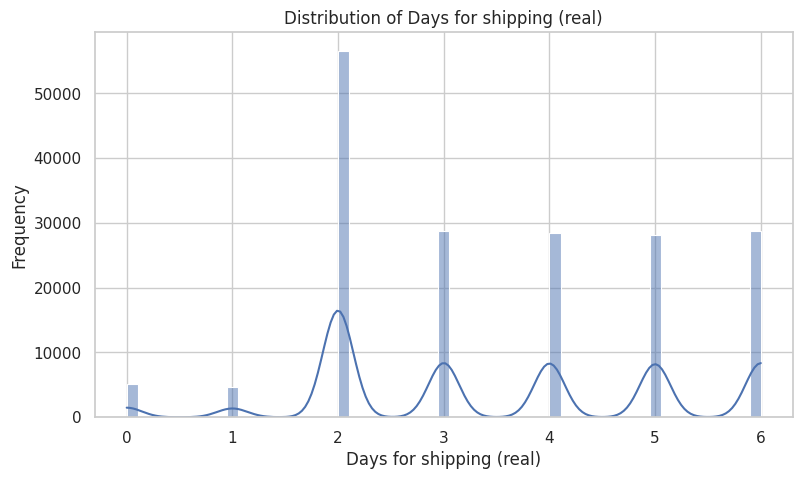

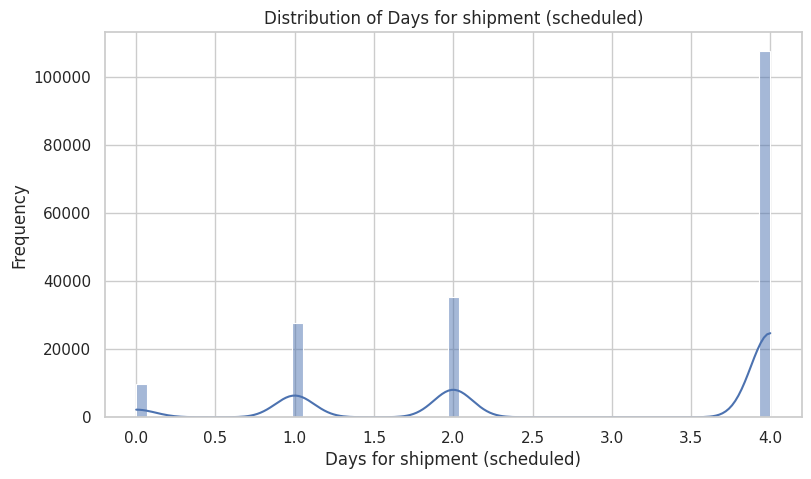

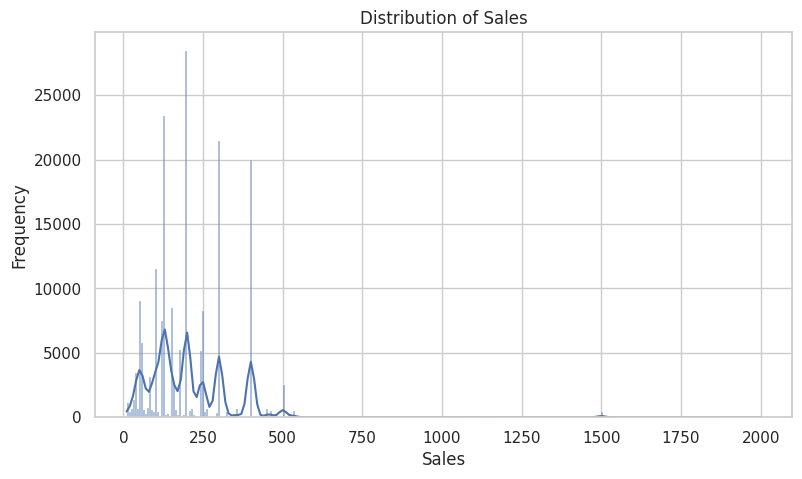

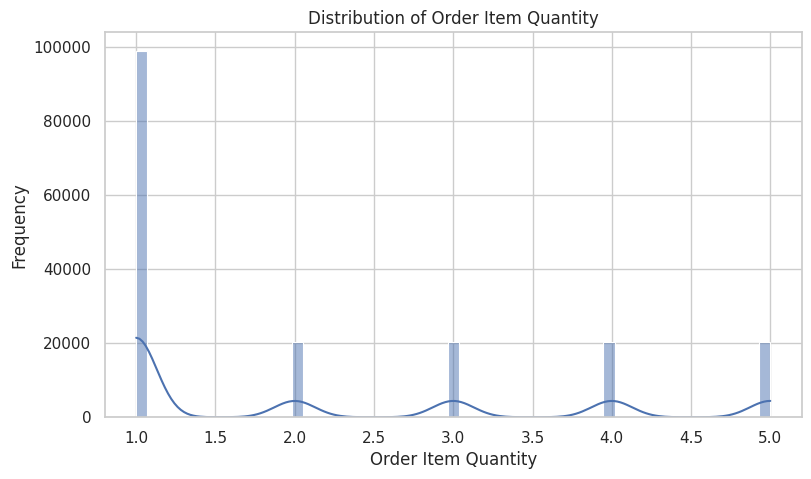

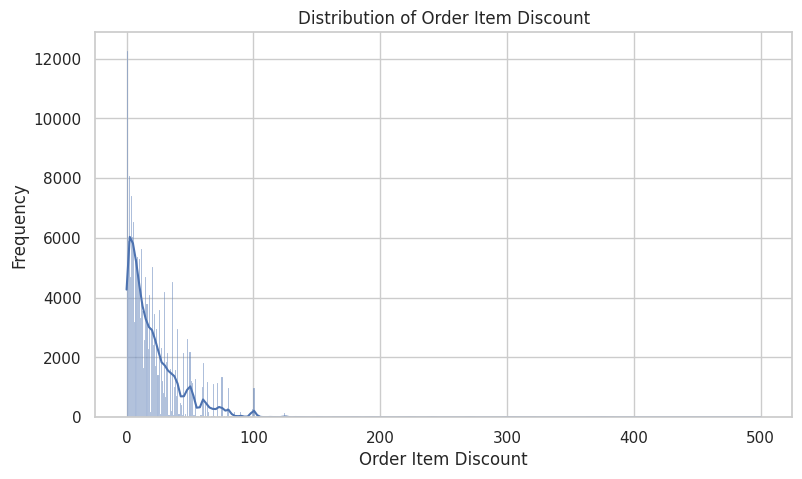

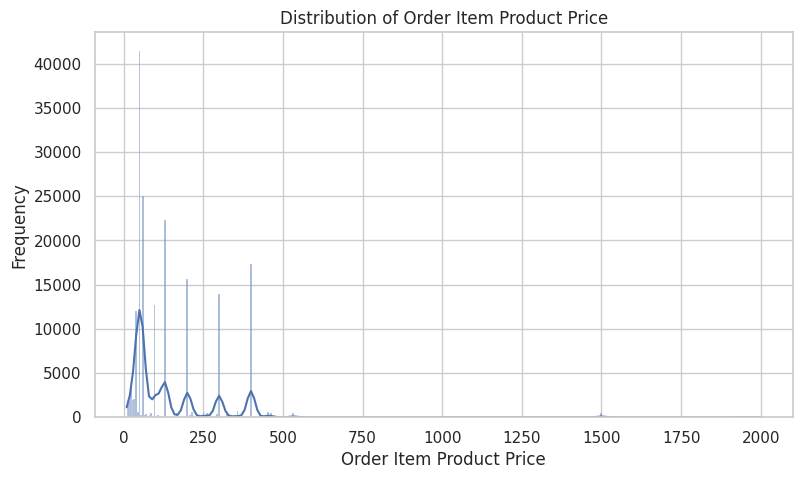

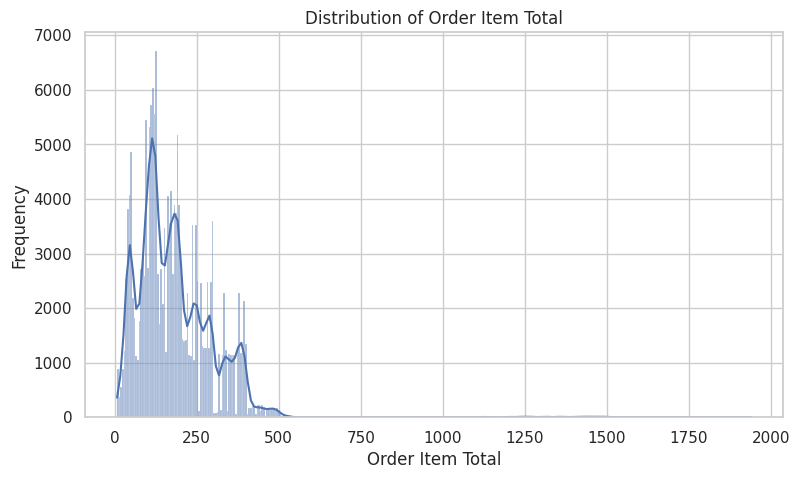

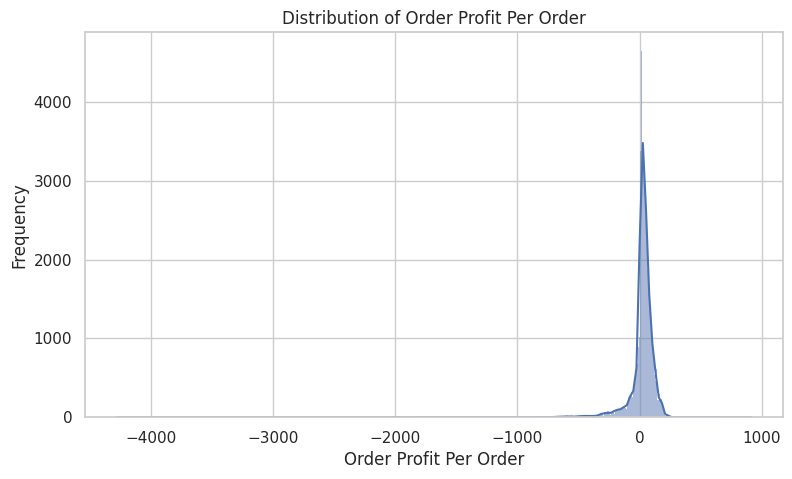

In [20]:
for col in available_numeric:

    plt.figure(figsize=(9, 5))

    sns.histplot(
        df[col].dropna(),
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

Boxplots

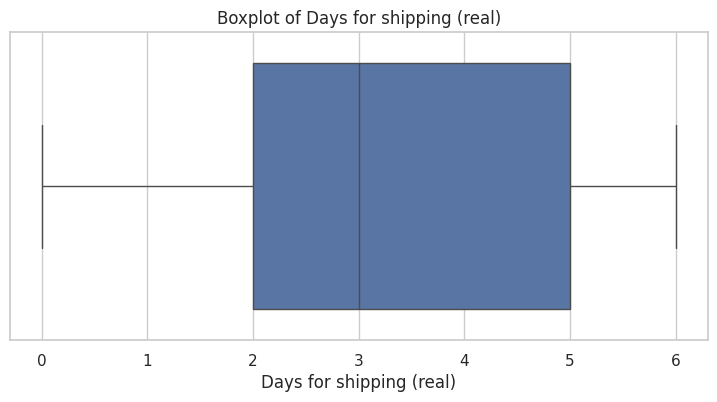

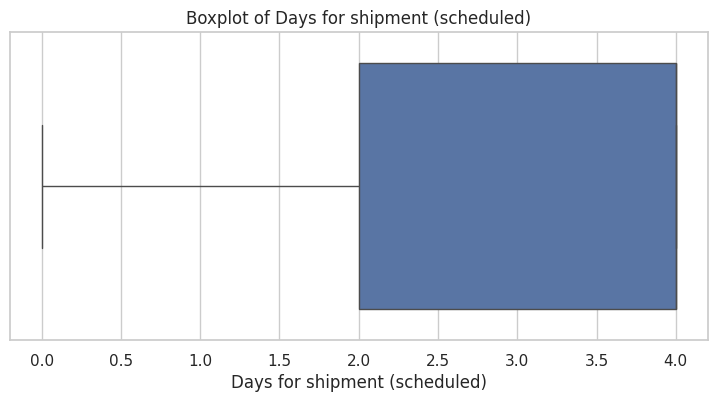

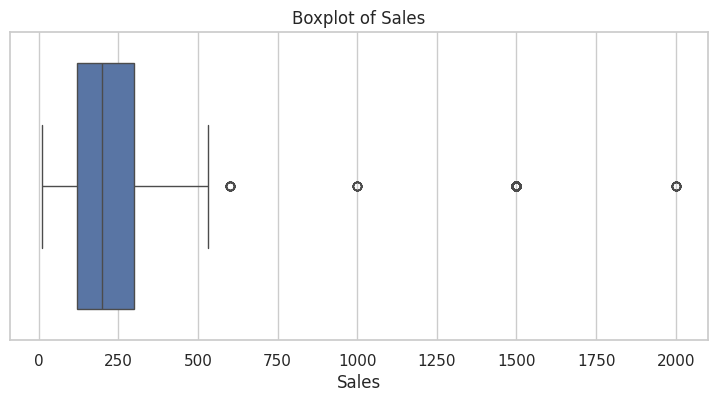

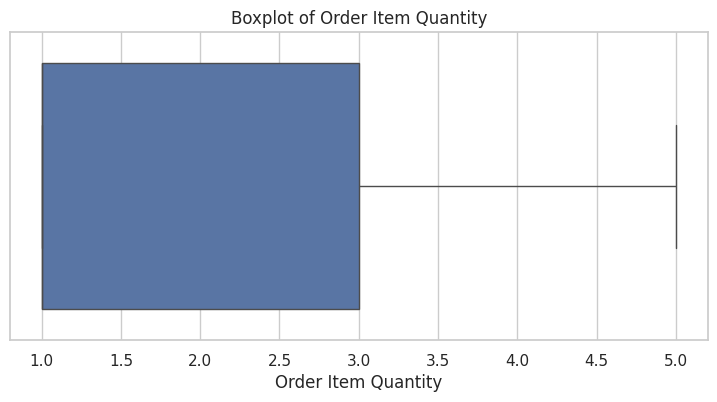

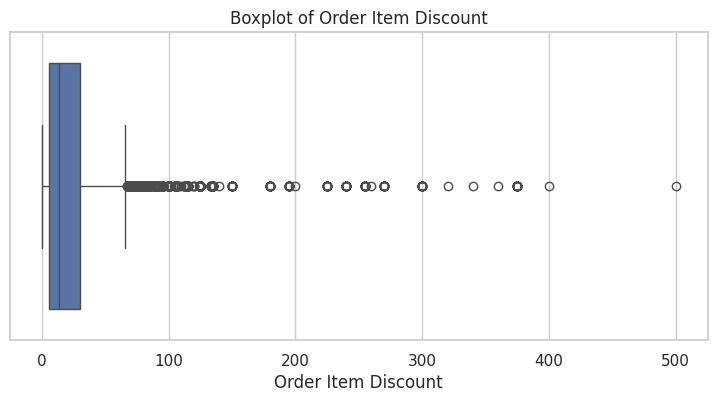

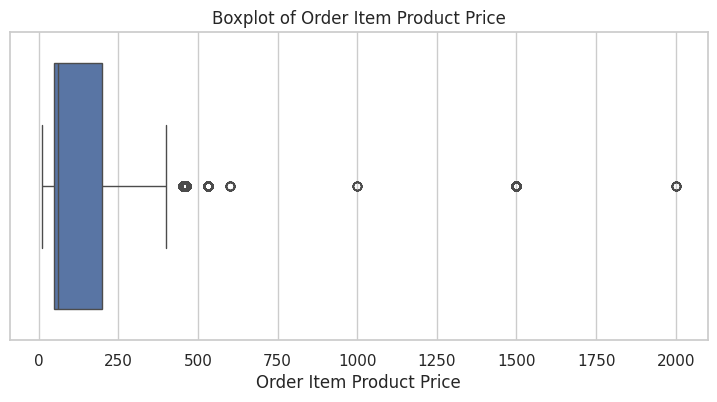

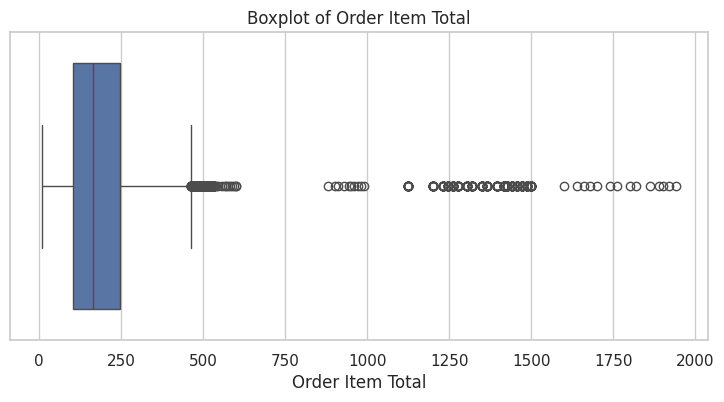

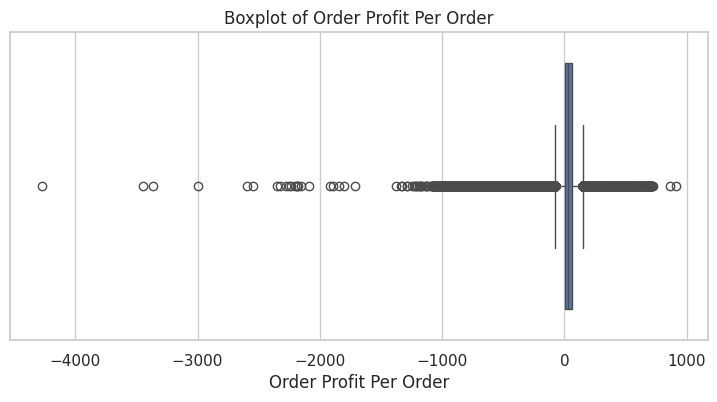

In [21]:
for col in available_numeric:

    plt.figure(figsize=(9, 4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.show()

Shipping Mode analysis

In [22]:
shipping_mode_delay = pd.crosstab(
    df["Shipping Mode"],
    df[TARGET],
    normalize="index"
) * 100

display(
    shipping_mode_delay.round(2)
)

Late_delivery_risk,0,1
Shipping Mode,,
First Class,4.68,95.32
Same Day,54.26,45.74
Second Class,23.37,76.63
Standard Class,61.93,38.07


Shipping Mode graph

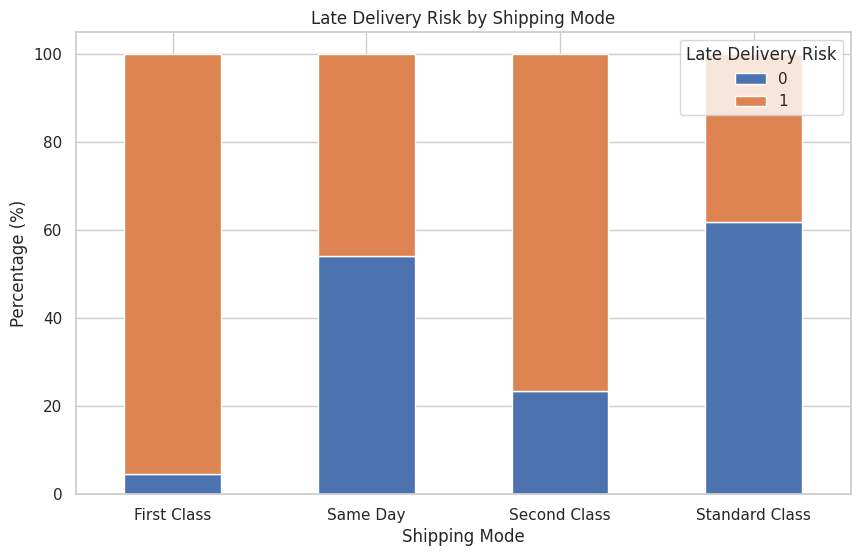

In [23]:
shipping_mode_delay.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Late Delivery Risk by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Percentage (%)")
plt.legend(title="Late Delivery Risk")

plt.xticks(rotation=0)

plt.show()

Categorical analysis


In [24]:
categorical_analysis_columns = [
    "Market",
    "Customer Segment",
    "Department Name",
    "Category Name",
    "Order Region",
    "Type"
]

available_categorical = [
    col for col in categorical_analysis_columns
    if col in df.columns
]

print(available_categorical)

['Market', 'Customer Segment', 'Department Name', 'Category Name', 'Order Region', 'Type']


Categorical delay tables

In [25]:
for col in available_categorical:

    print("\n" + "=" * 70)
    print(col)

    result = pd.crosstab(
        df[col],
        df[TARGET],
        normalize="index"
    ) * 100

    display(result.round(2))


Market


Late_delivery_risk,0,1
Market,,
Africa,45.41,54.59
Europe,44.79,55.21
LATAM,45.64,54.36
Pacific Asia,44.95,55.05
USCA,45.20,54.80



Customer Segment


Late_delivery_risk,0,1
Customer Segment,,
Consumer,45.19,54.81
Corporate,45.28,54.72
Home Office,44.93,55.07



Department Name


...

Late_delivery_risk,0,1
Category Name,,
Accessories,43.03,56.97
As Seen on TV!,42.65,57.35
Baby,47.34,52.66
Baseball & Softball,44.78,55.22
Basketball,44.78,55.22
Books,43.46,56.54
Boxing & MMA,43.74,56.26
CDs,47.97,52.03
Cameras,41.89,58.11



Order Region


Late_delivery_risk,0,1
Order Region,,
Canada,51.20,48.80
Caribbean,46.92,53.08
Central Africa,42.04,57.96
Central America,45.25,54.75
Central Asia,44.67,55.33
East Africa,44.06,55.94
East of USA,44.34,55.66
Eastern Asia,45.67,54.33
Eastern Europe,44.34,55.66



Type


Late_delivery_risk,0,1
Type,,
CASH,43.37,56.63
DEBIT,42.78,57.22
PAYMENT,42.47,57.53
TRANSFER,51.46,48.54


Categorical graphs

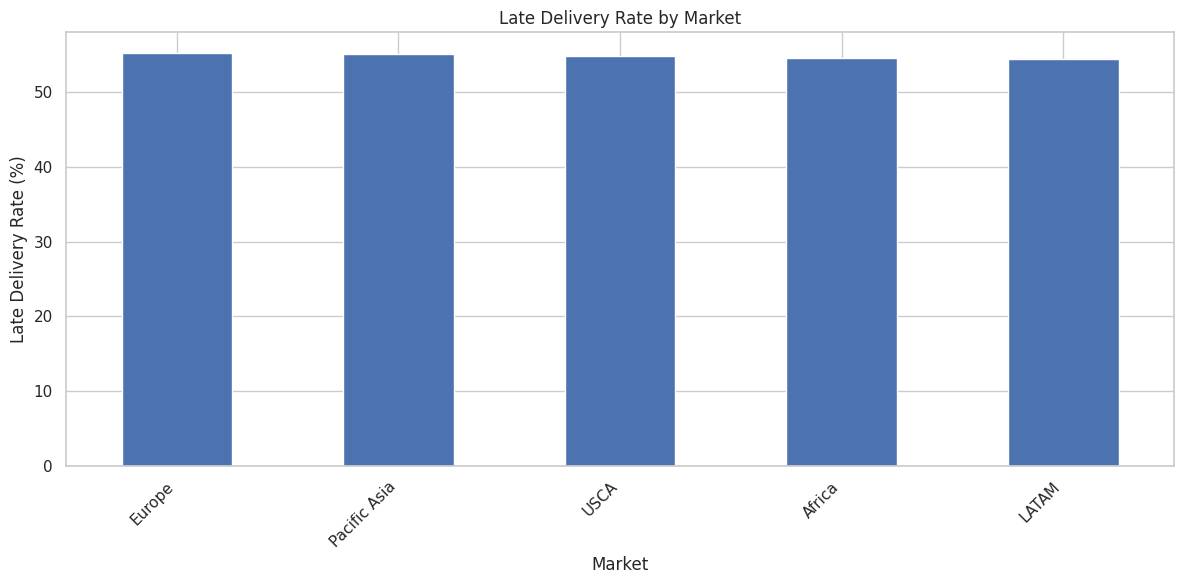

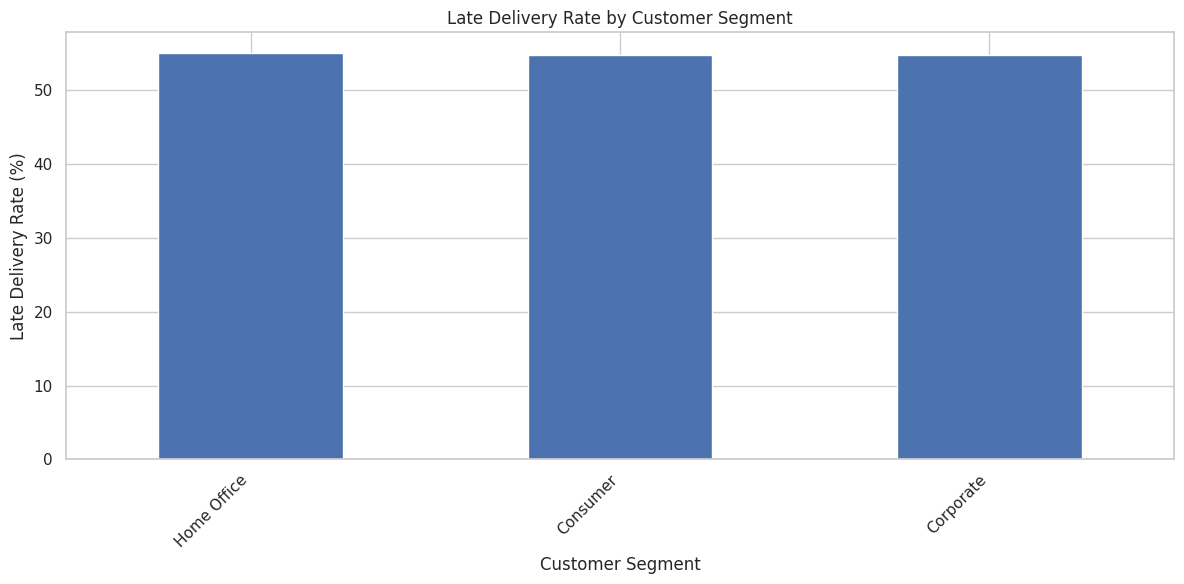

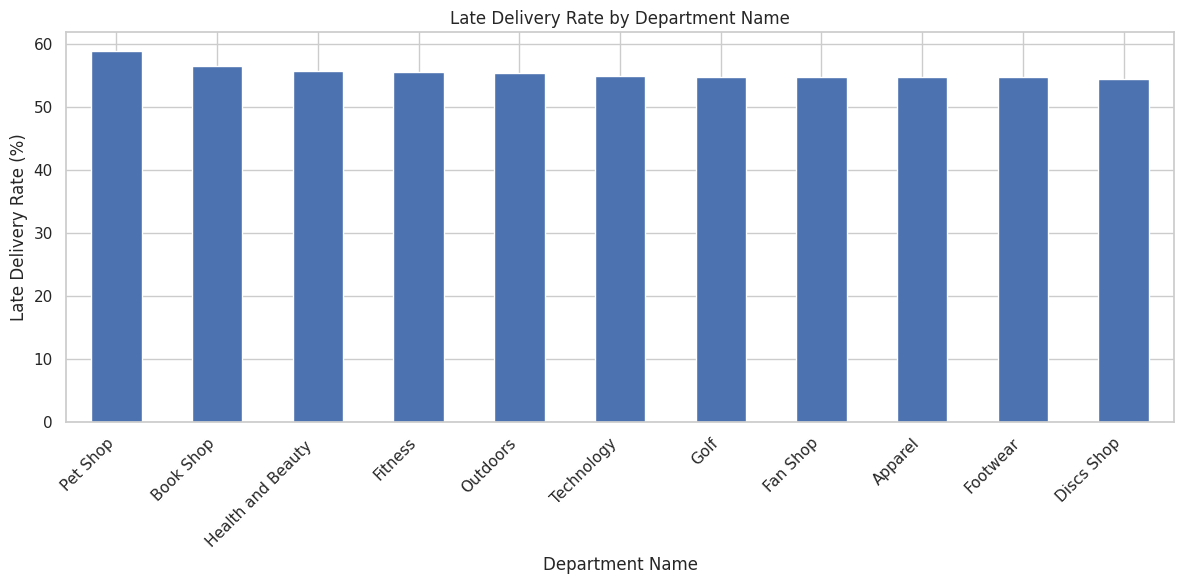

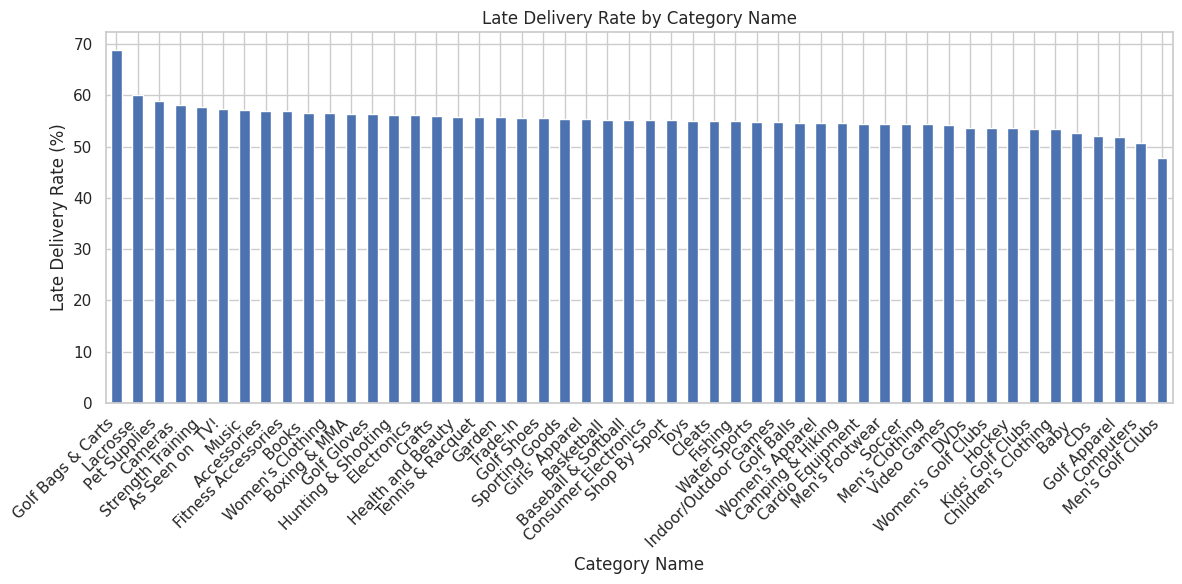

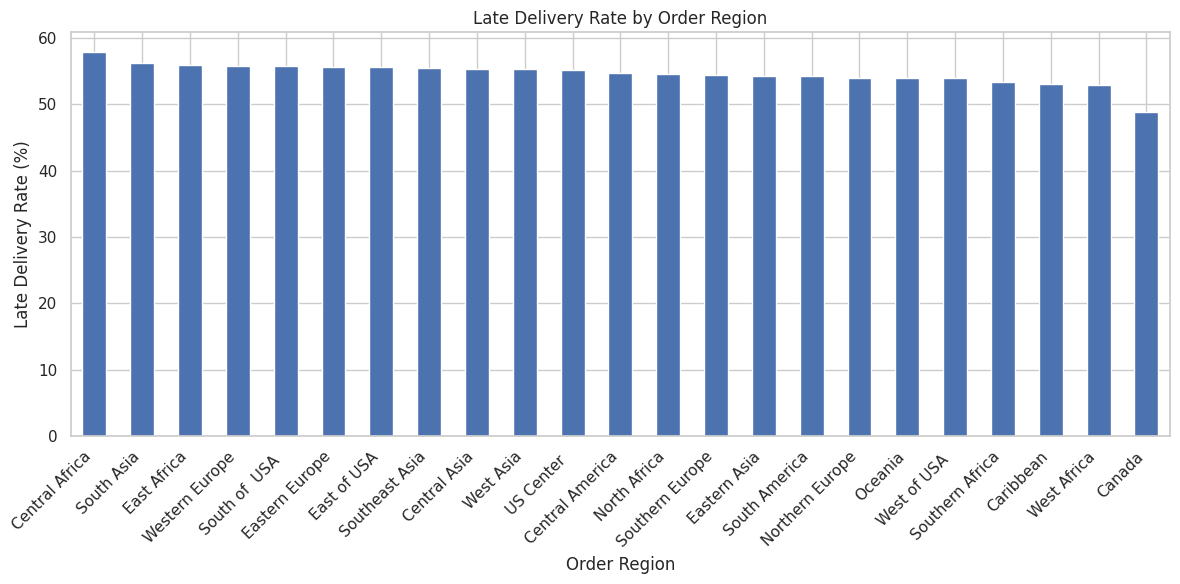

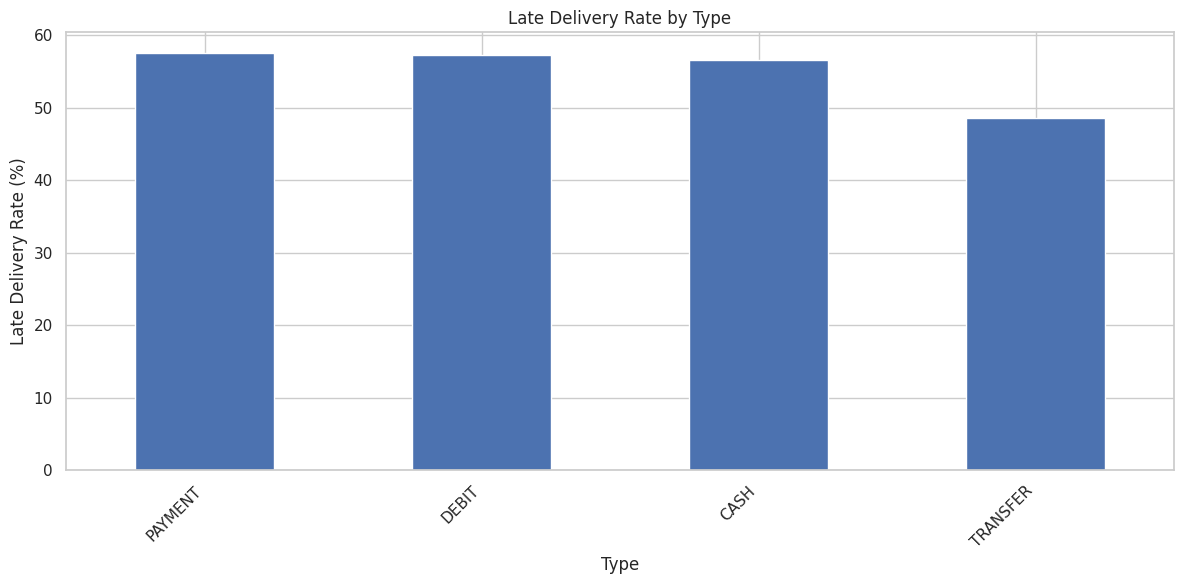

In [26]:
for col in available_categorical:

    result = pd.crosstab(
        df[col],
        df[TARGET],
        normalize="index"
    ) * 100

    plt.figure(figsize=(12, 6))

    result[1].sort_values(
        ascending=False
    ).plot(kind="bar")

    plt.title(
        f"Late Delivery Rate by {col}"
    )

    plt.xlabel(col)
    plt.ylabel("Late Delivery Rate (%)")

    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

Correlation analysis

In [27]:
correlation_matrix = df[
    numerical_columns
].corr()

target_correlation = (
    correlation_matrix[TARGET]
    .sort_values(ascending=False)
)

print("Correlation with Late_delivery_risk:")

display(
    target_correlation.to_frame(
        "Correlation"
    )
)

Correlation with Late_delivery_risk:


,Correlation
Late_delivery_risk,1.000000
Days for shipping (real),0.401415
Customer Zipcode,0.003148
Category Id,0.001752
Product Category Id,0.001752
Order Item Cardprod Id,0.001490
Product Card Id,0.001490
Order Customer Id,0.001484
Customer Id,0.001484
Department Id,0.001077


Correlation heatmap


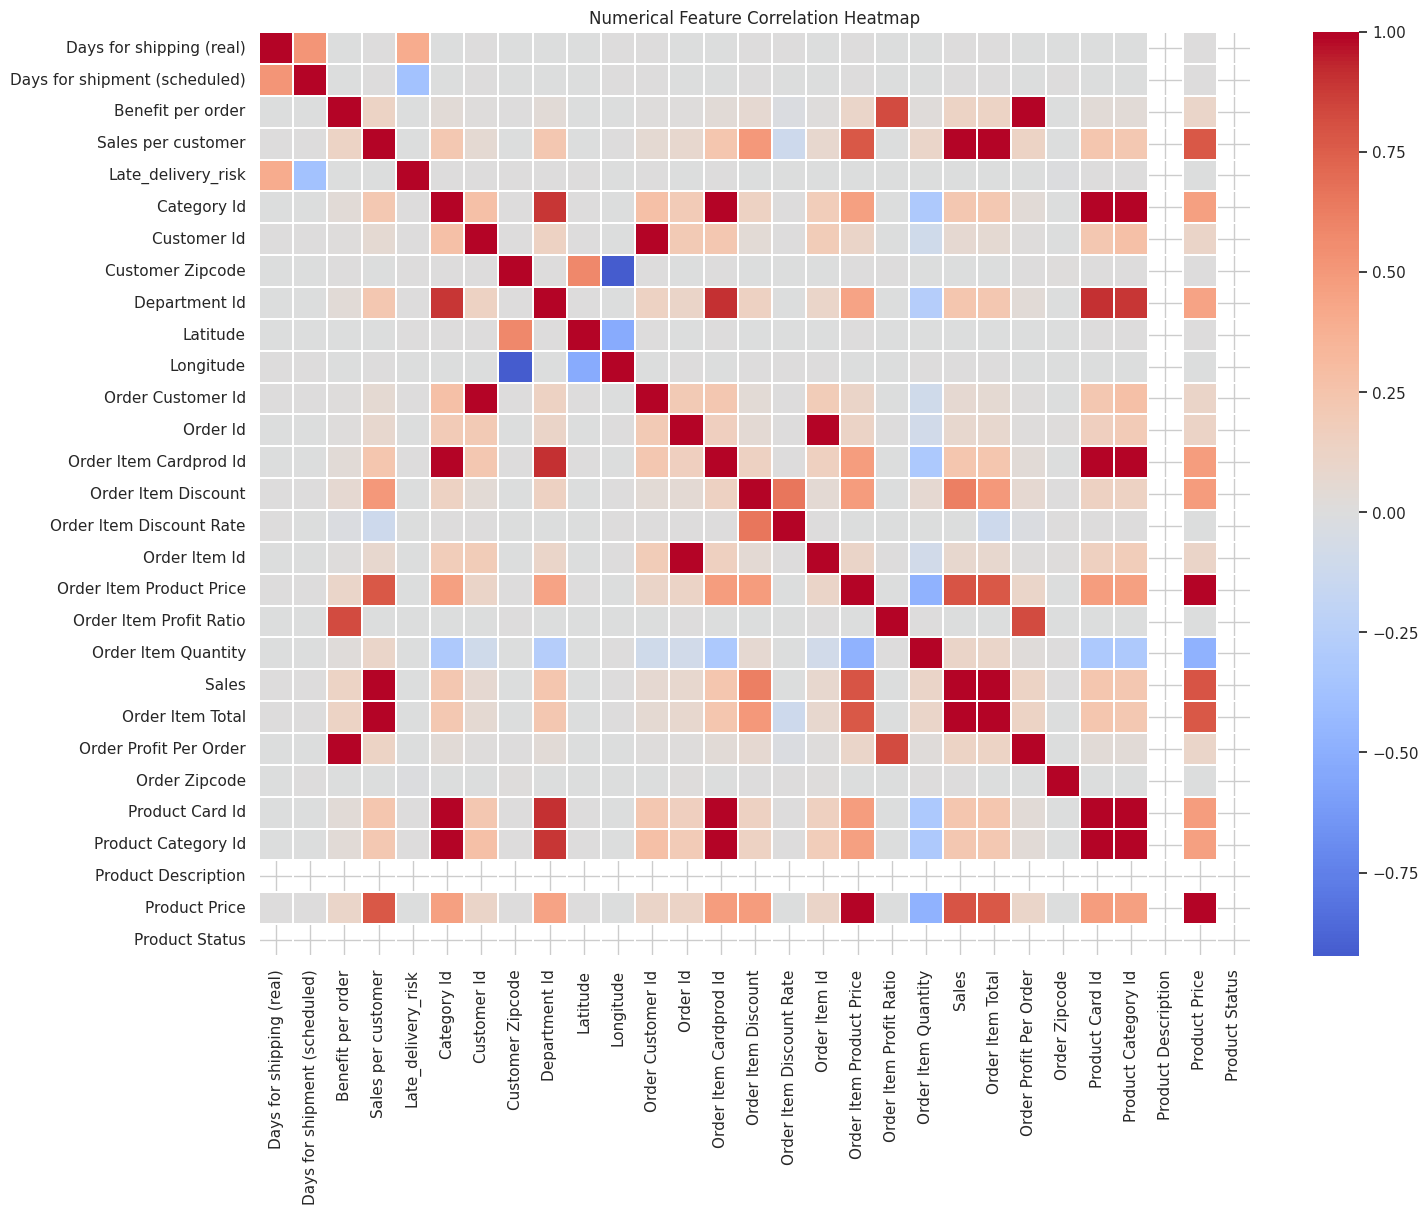

In [28]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Numerical Feature Correlation Heatmap")

plt.show()

Date columns

In [29]:
date_columns = [
    col for col in df.columns
    if "date" in col.lower()
]

print("Date-related columns:")
print(date_columns)

Date-related columns:
['order date (DateOrders)', 'shipping date (DateOrders)']


Convert dates

In [30]:
for col in date_columns:

    df[col] = pd.to_datetime(
        df[col],
        errors="coerce"
    )

print("Date conversion completed.")

Date conversion completed.


Create date features

In [31]:
if "order date (DateOrders)" in df.columns:

    df["Order_Year"] = (
        df["order date (DateOrders)"].dt.year
    )

    df["Order_Month"] = (
        df["order date (DateOrders)"].dt.month
    )

    df["Order_DayOfWeek"] = (
        df["order date (DateOrders)"].dt.dayofweek
    )

    df["Order_Day"] = (
        df["order date (DateOrders)"].dt.day
    )

print("Date features created.")

Date features created.


Monthly delay analysis


In [32]:
if "Order_Month" in df.columns:

    monthly_delay = pd.crosstab(
        df["Order_Month"],
        df[TARGET],
        normalize="index"
    ) * 100

    display(monthly_delay.round(2))

Late_delivery_risk,0,1
Order_Month,,
1,45.34,54.66
2,45.45,54.55
3,44.75,55.25
4,45.72,54.28
5,45.26,54.74
6,45.17,54.83
7,45.94,54.06
8,44.21,55.79
9,44.70,55.30


Monthly graph

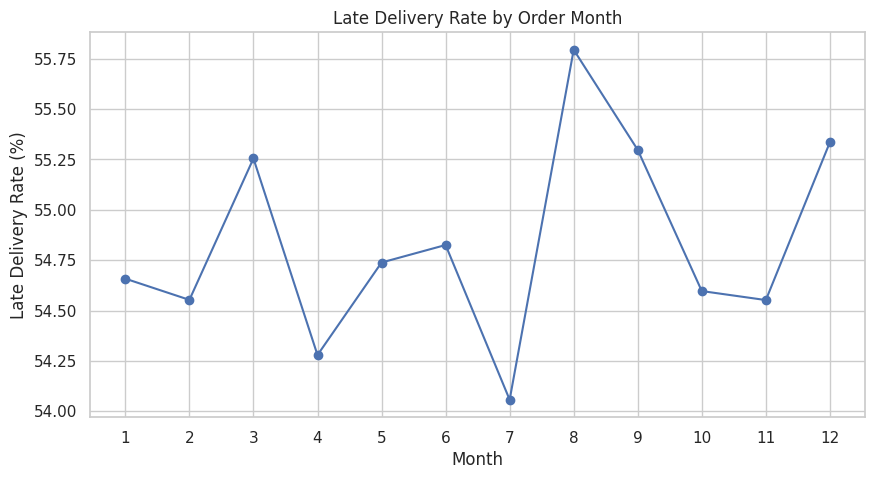

In [33]:
if "Order_Month" in df.columns:

    plt.figure(figsize=(10, 5))

    plt.plot(
        monthly_delay.index,
        monthly_delay[1],
        marker="o"
    )

    plt.title(
        "Late Delivery Rate by Order Month"
    )

    plt.xlabel("Month")
    plt.ylabel("Late Delivery Rate (%)")

    plt.xticks(range(1, 13))

    plt.show()

Day-of-week analysis

In [34]:
if "Order_DayOfWeek" in df.columns:

    weekday_delay = pd.crosstab(
        df["Order_DayOfWeek"],
        df[TARGET],
        normalize="index"
    ) * 100

    display(
        weekday_delay.round(2)
    )

Late_delivery_risk,0,1
Order_DayOfWeek,,
0,44.95,55.05
1,45.70,54.30
2,45.24,54.76
3,44.99,55.01
4,44.83,55.17
5,45.60,54.40
6,44.89,55.11


Leakage analysis

In [35]:
leakage_candidates = [
    "Late_delivery_risk",
    "Delivery Status",
    "Days for shipping (real)",
    "shipping date (DateOrders)"
]

leakage_table = []

for col in leakage_candidates:

    if col in df.columns:

        leakage_table.append({
            "Column": col,
            "Reason": ""
        })

leakage_table = pd.DataFrame(
    leakage_table
)

display(leakage_table)

,Column,Reason
0,Late_delivery_risk,
1,Delivery Status,
2,Days for shipping (real),
3,shipping date (DateOrders),


In [36]:
leakage_table = pd.DataFrame({
    "Column": [
        "Late_delivery_risk",
        "Delivery Status",
        "Days for shipping (real)",
        "shipping date (DateOrders)"
    ],
    "Decision": [
        "TARGET",
        "REMOVE",
        "REMOVE / INVESTIGATE",
        "REMOVE / INVESTIGATE"
    ],
    "Reason": [
        "This is the value we are trying to predict.",
        "Contains the shipment outcome/status and can reveal whether the shipment was late.",
        "Actual realized shipping duration may only be known after shipment execution.",
        "Shipping outcome timestamp may not be available at the intended pre-shipment prediction point."
    ]
})

display(leakage_table)

,Column,Decision,Reason
0,Late_delivery_risk,TARGET,This is the value we are trying to predict.
1,Delivery Status,REMOVE,Contains the shipment outcome/status and can r...
2,Days for shipping (real),REMOVE / INVESTIGATE,Actual realized shipping duration may only be ...
3,shipping date (DateOrders),REMOVE / INVESTIGATE,Shipping outcome timestamp may not be availabl...


identifier analysis

In [37]:
pii_and_identifier_candidates = [
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Customer Id",
    "Order Customer Id",
    "Order Id",
    "Order Item Id",
    "Order Item Cardprod Id",
    "Product Card Id",
    "Category Id",
    "Department Id"
]

pii_table = []

for col in pii_and_identifier_candidates:

    if col in df.columns:

        pii_table.append({
            "Column": col,
            "Decision": "REMOVE",
            "Reason": "PII / identifier / not appropriate as predictive feature"
        })

display(
    pd.DataFrame(pii_table)
)

,Column,Decision,Reason
0,Customer Email,REMOVE,PII / identifier / not appropriate as predicti...
1,Customer Password,REMOVE,PII / identifier / not appropriate as predicti...
2,Customer Fname,REMOVE,PII / identifier / not appropriate as predicti...
3,Customer Lname,REMOVE,PII / identifier / not appropriate as predicti...
4,Customer Street,REMOVE,PII / identifier / not appropriate as predicti...
5,Customer Id,REMOVE,PII / identifier / not appropriate as predicti...
6,Order Customer Id,REMOVE,PII / identifier / not appropriate as predicti...
7,Order Id,REMOVE,PII / identifier / not appropriate as predicti...
8,Order Item Id,REMOVE,PII / identifier / not appropriate as predicti...
9,Order Item Cardprod Id,REMOVE,PII / identifier / not appropriate as predicti...


Create final exclusion list

In [38]:
EXCLUDED_COLUMNS = [
    # Target
    "Late_delivery_risk",

    # Leakage / post-outcome
    "Delivery Status",
    "Days for shipping (real)",
    "shipping date (DateOrders)",

    # Missing / unusable
    "Product Description",
    "Order Zipcode",

    # PII
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",

    # Identifiers
    "Customer Id",
    "Order Customer Id",
    "Order Id",
    "Order Item Id",
    "Order Item Cardprod Id",
    "Product Card Id",
    "Category Id",
    "Department Id",

    # Other non-predictive fields
    "Product Image",
    "Product Status"
]

EXCLUDED_COLUMNS = [
    col for col in EXCLUDED_COLUMNS
    if col in df.columns
]

print("Excluded columns:")
for col in EXCLUDED_COLUMNS:
    print("-", col)

Excluded columns:
- Late_delivery_risk
- Delivery Status
- Days for shipping (real)
- shipping date (DateOrders)
- Product Description
- Order Zipcode
- Customer Email
- Customer Password
- Customer Fname
- Customer Lname
- Customer Street
- Customer Id
- Order Customer Id
- Order Id
- Order Item Id
- Order Item Cardprod Id
- Product Card Id
- Category Id
- Department Id
- Product Image
- Product Status


Candidate feature list

In [39]:
candidate_features = [
    col for col in df.columns
    if col not in EXCLUDED_COLUMNS
]

print("Number of candidate features:", len(candidate_features))

print("\nCandidate features:")
for col in candidate_features:
    print("-", col)

Number of candidate features: 36

Candidate features:
- Type
- Days for shipment (scheduled)
- Benefit per order
- Sales per customer
- Category Name
- Customer City
- Customer Country
- Customer Segment
- Customer State
- Customer Zipcode
- Department Name
- Latitude
- Longitude
- Market
- Order City
- Order Country
- order date (DateOrders)
- Order Item Discount
- Order Item Discount Rate
- Order Item Product Price
- Order Item Profit Ratio
- Order Item Quantity
- Sales
- Order Item Total
- Order Profit Per Order
- Order Region
- Order State
- Order Status
- Product Category Id
- Product Name
- Product Price
- Shipping Mode
- Order_Year
- Order_Month
- Order_DayOfWeek
- Order_Day


Final feature-selection table

In [40]:
feature_decisions = []

for col in df.columns:

    if col == TARGET:

        decision = "TARGET"
        reason = "Prediction target"

    elif col in EXCLUDED_COLUMNS:

        if col in [
            "Delivery Status",
            "Days for shipping (real)",
            "shipping date (DateOrders)"
        ]:
            decision = "REMOVE - LEAKAGE"
            reason = "Potentially reveals post-outcome information"

        elif col in [
            "Customer Email",
            "Customer Password",
            "Customer Fname",
            "Customer Lname",
            "Customer Street"
        ]:
            decision = "REMOVE - PII"
            reason = "Personally identifiable/sensitive information"

        elif col in [
            "Product Description",
            "Order Zipcode"
        ]:
            decision = "REMOVE - DATA QUALITY"
            reason = "Unavailable / overwhelmingly missing"

        else:
            decision = "REMOVE - IDENTIFIER"
            reason = "Identifier or non-predictive field"

    else:

        decision = "CANDIDATE FEATURE"
        reason = "Potentially available at prediction time"

    feature_decisions.append({
        "Column": col,
        "Decision": decision,
        "Reason": reason
    })

feature_decisions = pd.DataFrame(
    feature_decisions
)

display(feature_decisions)

,Column,Decision,Reason
0,Type,CANDIDATE FEATURE,Potentially available at prediction time
1,Days for shipping (real),REMOVE - LEAKAGE,Potentially reveals post-outcome information
2,Days for shipment (scheduled),CANDIDATE FEATURE,Potentially available at prediction time
3,Benefit per order,CANDIDATE FEATURE,Potentially available at prediction time
4,Sales per customer,CANDIDATE FEATURE,Potentially available at prediction time
5,Delivery Status,REMOVE - LEAKAGE,Potentially reveals post-outcome information
6,Late_delivery_risk,TARGET,Prediction target
7,Category Id,REMOVE - IDENTIFIER,Identifier or non-predictive field
8,Category Name,CANDIDATE FEATURE,Potentially available at prediction time
9,Customer City,CANDIDATE FEATURE,Potentially available at prediction time


Create cleaned dataset


In [41]:
clean_df = df.copy()

# Remove exact duplicate rows
clean_df = clean_df.drop_duplicates()

# Drop columns that are unusable for the initial project
cleaning_drop = [
    col for col in [
        "Product Description",
        "Order Zipcode"
    ]
    if col in clean_df.columns
]

clean_df = clean_df.drop(
    columns=cleaning_drop
)

print("Original shape:", df.shape)
print("Cleaned shape:", clean_df.shape)

Original shape: (180519, 57)
Cleaned shape: (180519, 55)


Shared feature-engineering function

In [42]:
def engineer_features(data):

    X = data.copy()

    # Date features
    if "order date (DateOrders)" in X.columns:

        date_series = pd.to_datetime(
            X["order date (DateOrders)"],
            errors="coerce"
        )

        X["Order_Year"] = date_series.dt.year
        X["Order_Month"] = date_series.dt.month
        X["Order_Day"] = date_series.dt.day
        X["Order_DayOfWeek"] = date_series.dt.dayofweek

        X.drop(
            columns=["order date (DateOrders)"],
            inplace=True
        )

    # Remove target, leakage, PII and identifiers
    feature_exclusions = [
        "Late_delivery_risk",
        "Delivery Status",
        "Days for shipping (real)",
        "shipping date (DateOrders)",

        "Customer Email",
        "Customer Password",
        "Customer Fname",
        "Customer Lname",
        "Customer Street",

        "Customer Id",
        "Order Customer Id",
        "Order Id",
        "Order Item Id",
        "Order Item Cardprod Id",
        "Product Card Id",
        "Category Id",
        "Department Id",

        "Product Image",
        "Product Status"
    ]

    feature_exclusions = [
        col for col in feature_exclusions
        if col in X.columns
    ]

    X = X.drop(
        columns=feature_exclusions
    )

    return X

Generate X and y

In [43]:
X = engineer_features(clean_df)

y = clean_df[TARGET].astype(int)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (180519, 35)
Target shape: (180519,)

Target distribution:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64


Check final features

In [44]:
final_feature_table = pd.DataFrame({
    "Feature": X.columns,
    "Data_Type": X.dtypes.astype(str).values,
    "Unique_Values": [
        X[col].nunique(dropna=True)
        for col in X.columns
    ],
    "Missing_Count": [
        X[col].isna().sum()
        for col in X.columns
    ]
})

display(final_feature_table)

,Feature,Data_Type,Unique_Values,Missing_Count
0,Type,object,4,0
1,Days for shipment (scheduled),int64,4,0
2,Benefit per order,float64,21998,0
3,Sales per customer,float64,2927,0
4,Category Name,object,50,0
5,Customer City,object,563,0
6,Customer Country,object,2,0
7,Customer Segment,object,3,0
8,Customer State,object,46,0
9,Customer Zipcode,float64,995,3


In [45]:
# ============================================================
# CREATE FINAL PROCESSED DATASET
# ============================================================

# Start from the engineered feature matrix
processed = X.copy()

# Add target
processed[TARGET] = y.values

# Remove remaining column with missing values
if "Customer Zipcode" in processed.columns:
    processed = processed.drop(columns=["Customer Zipcode"])

print("Final processed dataset created.")
print("Shape:", processed.shape)
print("Missing values:", processed.isnull().sum().sum())

Final processed dataset created.
Shape: (180519, 35)
Missing values: 0


FINAL VERIFICATION

In [46]:
# ============================================================
# FINAL DATASET VERIFICATION
# ============================================================

print("=" * 70)
print("FINAL PROCESSED DATASET VERIFICATION")
print("=" * 70)

missing_count = processed.isnull().sum().sum()
duplicate_count = processed.duplicated().sum()

numeric_data = processed.select_dtypes(include=np.number)

infinite_count = np.isinf(numeric_data).sum().sum()

leakage_columns = [
    "Delivery Status",
    "Days for shipping (real)",
    "shipping date (DateOrders)"
]

remaining_leakage = [
    col for col in leakage_columns
    if col in processed.columns
]

print("\nShape:")
print(processed.shape)

print("\nMissing values:")
print(missing_count)

print("\nDuplicate rows:")
print(duplicate_count)

print("\nInfinite values:")
print(infinite_count)

print("\nTarget:")
print(processed[TARGET].value_counts())

print("\nLeakage columns remaining:")

if remaining_leakage:
    print(remaining_leakage)
else:
    print("PASS - None")

print("\n" + "=" * 70)
print("FINAL STATUS")
print("=" * 70)

if (
    missing_count == 0
    and duplicate_count == 0
    and infinite_count == 0
    and len(remaining_leakage) == 0
):
    print("✅ DATASET PASSES SECTION 1 PREPROCESSING CHECKS")
else:
    print("⚠️ DATASET STILL REQUIRES ATTENTION")

FINAL PROCESSED DATASET VERIFICATION

Shape:
(180519, 35)

Missing values:
0

Duplicate rows:
0

Infinite values:
0

Target:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Leakage columns remaining:
PASS - None

FINAL STATUS
✅ DATASET PASSES SECTION 1 PREPROCESSING CHECKS


Save processed dataset

In [47]:
os.makedirs("processed_data", exist_ok=True)

processed_file = (
    "processed_data/"
    "supply_prescript_features.csv"
)

final_df = X.copy()
final_df[TARGET] = y.values

final_df.to_csv(
    processed_file,
    index=False
)

print(
    f"Processed dataset saved to: {processed_file}"
)

print(
    "Final shape:",
    final_df.shape
)

Processed dataset saved to: processed_data/supply_prescript_features.csv
Final shape: (180519, 36)


Save feature documentation

In [48]:
feature_decisions.to_csv(
    "processed_data/feature_selection.csv",
    index=False
)

missing_report.to_csv(
    "processed_data/missing_value_report.csv"
)

outlier_report.to_csv(
    "processed_data/outlier_report.csv",
    index=False
)

target_summary.to_csv(
    "processed_data/target_summary.csv"
)

print("Analysis reports saved.")

Analysis reports saved.


Final missing-value report

In [49]:
# ============================================================
# FINAL MISSING VALUE REPORT
# ============================================================

final_missing_report = pd.DataFrame({
    "Column": processed.columns,
    "Missing_Count": [
        processed[col].isnull().sum()
        for col in processed.columns
    ],
    "Missing_Percentage": [
        processed[col].isnull().mean() * 100
        for col in processed.columns
    ]
})

display(final_missing_report)

final_missing_report.to_csv(
    "processed_data/missing_value_report.csv",
    index=False
)

print("Final missing-value report saved.")

,Column,Missing_Count,Missing_Percentage
0,Type,0,0.0
1,Days for shipment (scheduled),0,0.0
2,Benefit per order,0,0.0
3,Sales per customer,0,0.0
4,Category Name,0,0.0
5,Customer City,0,0.0
6,Customer Country,0,0.0
7,Customer Segment,0,0.0
8,Customer State,0,0.0
9,Department Name,0,0.0


Final missing-value report saved.


Verification report

In [50]:
# ============================================================
# FINAL VERIFICATION REPORT
# ============================================================

verification = pd.DataFrame({
    "Check": [
        "No missing values",
        "No duplicate rows",
        "No infinite values",
        "No identified leakage columns",
        "Target exists"
    ],
    "Status": [
        "PASS" if missing_count == 0 else "FAIL",
        "PASS" if duplicate_count == 0 else "FAIL",
        "PASS" if infinite_count == 0 else "FAIL",
        "PASS" if len(remaining_leakage) == 0 else "FAIL",
        "PASS" if TARGET in processed.columns else "FAIL"
    ]
})

display(verification)

verification.to_csv(
    "processed_data/preprocessing_verification.csv",
    index=False
)

print("Verification report saved.")

,Check,Status
0,No missing values,PASS
1,No duplicate rows,PASS
2,No infinite values,PASS
3,No identified leakage columns,PASS
4,Target exists,PASS


Verification report saved.


Final project summary

In [51]:
# ============================================================
# SUPPLYPRESCRIPT - SECTION 1 FINAL SUMMARY
# ============================================================

print("=" * 70)
print("SUPPLYPRESCRIPT - SECTION 1 FINAL SUMMARY")
print("=" * 70)

print("\nOriginal dataset:")
print(f"{df.shape[0]:,} rows × {df.shape[1]} columns")

print("\nFinal processed dataset:")
print(
    f"{processed.shape[0]:,} rows × "
    f"{processed.shape[1]} columns"
)

print("\nTarget:")
print(TARGET)

print("\nTarget distribution:")

target_percent = (
    processed[TARGET]
    .value_counts(normalize=True) * 100
)

print(target_percent.round(2).to_string())

print("\nDuplicate rows:")
print(duplicate_count)

print("\nMissing values:")
print(missing_count)

print("\nInfinite values:")
print(infinite_count)

print("\nLeakage columns remaining:")

if remaining_leakage:
    print(remaining_leakage)
else:
    print("None")

print("\nFinal feature columns:")
print(processed.shape[1] - 1)

print("\n" + "=" * 70)
print("SECTION 1 STATUS")
print("=" * 70)

if (
    missing_count == 0
    and duplicate_count == 0
    and infinite_count == 0
    and len(remaining_leakage) == 0
):
    print("✅ SECTION 1 DATA FOUNDATION PASSES FINAL CHECKS")
else:
    print("⚠️ SECTION 1 STILL REQUIRES ATTENTION")

SUPPLYPRESCRIPT - SECTION 1 FINAL SUMMARY

Original dataset:
180,519 rows × 57 columns

Final processed dataset:
180,519 rows × 35 columns

Target:
Late_delivery_risk

Target distribution:
Late_delivery_risk
1    54.83
0    45.17

Duplicate rows:
0

Missing values:
0

Infinite values:
0

Leakage columns remaining:
None

Final feature columns:
34

SECTION 1 STATUS
✅ SECTION 1 DATA FOUNDATION PASSES FINAL CHECKS


Download the results

In [52]:
from google.colab import files
import shutil

shutil.make_archive(
    "SupplyPrescript_Section1_results",
    "zip",
    "processed_data"
)

files.download(
    "SupplyPrescript_Section1_results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>